<a href="https://colab.research.google.com/github/qjasrubang01-design/CPE-311-Github-Repository-for-Data-Science-1/blob/main/Transfer_Learning_on_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transfer Learning using PyTorch

In [ ]:
!nvidia-smi

Thu Feb 19 07:22:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   53C    P0             27W /   70W |     223MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load Important Libraries

In [ ]:
# License: BSD
# Author: Sasank Chilamkurthy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory

cudnn.benchmark = True
plt.ion()   # interactive mode

## Load Data
=========

We will use torchvision and torch.utils.data packages for loading the
data.

The problem we\'re going to solve today is to train a model to classify
**ants** and **bees**. We have about 120 training images each for ants
and bees. There are 75 validation images for each class. Usually, this
is a very small dataset to generalize upon, if trained from scratch.
Since we are using transfer learning, we should be able to generalize
reasonably well.

This dataset is a very small subset of imagenet.


In [ ]:
!rm -R /content/hymenoptera_data/train/.ipynb_checkpoints
!ls /content/drive/MyDrive/CPE 313/hymenoptera_data/train -a   #to make sure that the deletion has occurred

!rm -R /content/hymenoptera_data/val/.ipynb_checkpoints
!ls /content/drive/MyDrive/CPE 313/hymenoptera_data/val -a   #to make sure that the deletion has occurred

rm: cannot remove '/content/hymenoptera_data/train/.ipynb_checkpoints': No such file or directory
ls: cannot access '/content/drive/MyDrive/CPE': No such file or directory
ls: cannot access '313/hymenoptera_data/train': No such file or directory
rm: cannot remove '/content/hymenoptera_data/val/.ipynb_checkpoints': No such file or directory
ls: cannot access '/content/drive/MyDrive/CPE': No such file or directory
ls: cannot access '313/hymenoptera_data/val': No such file or directory


In [ ]:
# Data augmentation and normalization for training
# Just normalization for validation
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = '/content/drive/MyDrive/CPE 313/hymenoptera_data'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True, num_workers=4)
              for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

# We want to be able to train our model on an `accelerator <https://pytorch.org/docs/stable/torch.html#accelerators>`__
# such as CUDA, MPS, MTIA, or XPU. If the current accelerator is available, we will use it. Otherwise, we use the CPU.

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


## Visualize a few images
======================

Let\'s visualize a few training images so as to understand the data
augmentations.


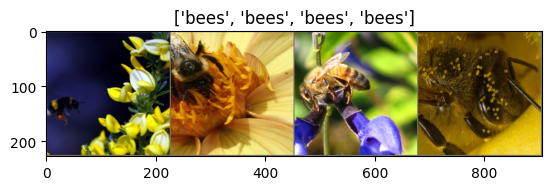

In [ ]:
def imshow(inp, title=None):
    """Display image for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

## Training the model
==================

Now, let\'s write a general function to train a model. Here, we will
illustrate:

-   Scheduling the learning rate
-   Saving the best model

In the following, parameter `scheduler` is an LR scheduler object from
`torch.optim.lr_scheduler`.


In [ ]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    # Create a temporary directory to save training checkpoints
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            # Each epoch has a training and validation phase
            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()  # Set model to training mode
                else:
                    model.eval()   # Set model to evaluate mode

                running_loss = 0.0
                running_corrects = 0

                # Iterate over data.
                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    # zero the parameter gradients
                    optimizer.zero_grad()

                    # forward
                    # track history if only in train
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        # backward + optimize only if in training phase
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # statistics
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                if phase == 'train':
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                # deep copy the model
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        # load best model weights
        model.load_state_dict(torch.load(best_model_params_path, weights_only=True))
    return model

## Visualizing the model predictions
=================================

Generic function to display predictions for a few images


In [ ]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

## Finetuning the ConvNet
======================

Load a pretrained model and reset final fully connected layer.


In [ ]:
model_ft = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model_ft.fc.in_features
# Here the size of each output sample is set to 2.
# Alternatively, it can be generalized to ``nn.Linear(num_ftrs, len(class_names))``.
model_ft.fc = nn.Linear(num_ftrs, 2)

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

## Train and evaluate
==================

It should take around 15-25 min on CPU. On GPU though, it takes less
than a minute.


In [ ]:
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=25)

Epoch 0/24
----------
train Loss: 0.5887 Acc: 0.7049
val Loss: 0.3175 Acc: 0.9020

Epoch 1/24
----------
train Loss: 0.5780 Acc: 0.7828
val Loss: 0.4298 Acc: 0.8497

Epoch 2/24
----------
train Loss: 0.5585 Acc: 0.7869
val Loss: 0.3142 Acc: 0.8497

Epoch 3/24
----------
train Loss: 0.6068 Acc: 0.7664
val Loss: 0.3283 Acc: 0.8954

Epoch 4/24
----------
train Loss: 0.4713 Acc: 0.7828
val Loss: 0.2618 Acc: 0.9020

Epoch 5/24
----------
train Loss: 0.4350 Acc: 0.8443
val Loss: 0.2264 Acc: 0.9216

Epoch 6/24
----------
train Loss: 0.3819 Acc: 0.8443
val Loss: 0.2962 Acc: 0.9085

Epoch 7/24
----------
train Loss: 0.3789 Acc: 0.8525
val Loss: 0.3139 Acc: 0.8824

Epoch 8/24
----------
train Loss: 0.3152 Acc: 0.8730
val Loss: 0.2957 Acc: 0.8758

Epoch 9/24
----------
train Loss: 0.2601 Acc: 0.8730
val Loss: 0.2634 Acc: 0.9085

Epoch 10/24
----------
train Loss: 0.2364 Acc: 0.9016
val Loss: 0.2431 Acc: 0.9281

Epoch 11/24
----------
train Loss: 0.2712 Acc: 0.8689
val Loss: 0.2328 Acc: 0.9150

Ep

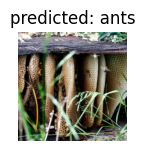

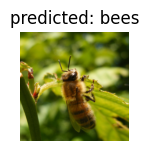

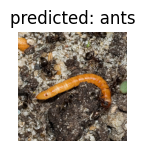

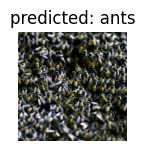

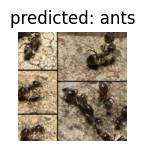

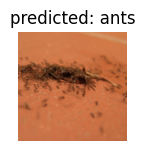

In [ ]:
visualize_model(model_ft)

In [ ]:
model_ft.layer1

Sequential(
  (0): BasicBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (1): BasicBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
)

## ConvNet as fixed feature extractor
==================================

Here, we need to freeze all the network except the final layer. We need
to set `requires_grad = False` to freeze the parameters so that the
gradients are not computed in `backward()`.

You can read more about this in the documentation
[here](https://pytorch.org/docs/notes/autograd.html#excluding-subgraphs-from-backward).


In [ ]:
model_conv = torchvision.models.resnet18(weights='IMAGENET1K_V1')
for param in model_conv.parameters():
    param.requires_grad = False

# Parameters of newly constructed modules have requires_grad=True by default
num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, 2)

model_conv = model_conv.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that only parameters of final layer are being optimized as
# opposed to before.
optimizer_conv = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

## Train and evaluate
==================

On CPU this will take about half the time compared to previous scenario.
This is expected as gradients don\'t need to be computed for most of the
network. However, forward does need to be computed.


In [ ]:
model_conv = train_model(model_conv, criterion, optimizer_conv,
                         exp_lr_scheduler, num_epochs=25)

Epoch 0/24
----------
train Loss: 0.6584 Acc: 0.6230
val Loss: 0.2357 Acc: 0.9150

Epoch 1/24
----------
train Loss: 0.5792 Acc: 0.7336
val Loss: 0.1940 Acc: 0.9412

Epoch 2/24
----------
train Loss: 0.5349 Acc: 0.7541
val Loss: 0.1857 Acc: 0.9412

Epoch 3/24
----------
train Loss: 0.3390 Acc: 0.8525
val Loss: 0.3922 Acc: 0.8497

Epoch 4/24
----------
train Loss: 0.4699 Acc: 0.8033
val Loss: 0.1658 Acc: 0.9608

Epoch 5/24
----------
train Loss: 0.4642 Acc: 0.8115
val Loss: 0.1587 Acc: 0.9477

Epoch 6/24
----------
train Loss: 0.3812 Acc: 0.8156
val Loss: 0.1970 Acc: 0.9281

Epoch 7/24
----------
train Loss: 0.3842 Acc: 0.8279
val Loss: 0.1594 Acc: 0.9542

Epoch 8/24
----------
train Loss: 0.3302 Acc: 0.8402
val Loss: 0.1697 Acc: 0.9477

Epoch 9/24
----------
train Loss: 0.4019 Acc: 0.8484
val Loss: 0.1768 Acc: 0.9477

Epoch 10/24
----------
train Loss: 0.3196 Acc: 0.8730
val Loss: 0.1665 Acc: 0.9542

Epoch 11/24
----------
train Loss: 0.3835 Acc: 0.8361
val Loss: 0.2031 Acc: 0.9216

Ep

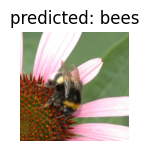

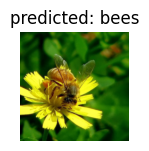

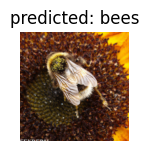

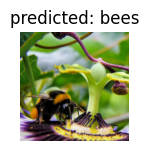

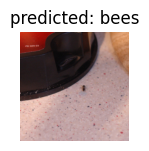

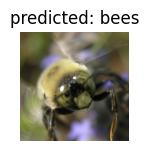

In [ ]:
visualize_model(model_conv)

plt.ioff()
plt.show()

## Inference on custom images
==========================

Use the trained model to make predictions on custom images and visualize
the predicted class labels along with the images.


In [ ]:
def visualize_model_predictions(model,img_path):
    was_training = model.training
    model.eval()

    img = Image.open(img_path)
    img = data_transforms['val'](img)
    img = img.unsqueeze(0)
    img = img.to(device)

    with torch.no_grad():
        outputs = model(img)
        _, preds = torch.max(outputs, 1)

        ax = plt.subplot(2,2,1)
        ax.axis('off')
        ax.set_title(f'Predicted: {class_names[preds[0]]}')
        imshow(img.cpu().data[0])

        model.train(mode=was_training)

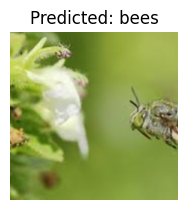

In [ ]:
visualize_model_predictions(
    model_conv,
    img_path='/content/beee.jpg'
)

plt.ioff()
plt.show()

## Further Learning
================

If you would like to learn more about the applications of transfer
learning, checkout the
* [Quantized Transfer Learning for Computer Vision
Tutorial](https://pytorch.org/tutorials/intermediate/quantized_transfer_learning_tutorial.html).


# Supplementary Activity

In a new notebook, perform the following:
1. Choose a pretrained model.
2. Finetune on your dataset from the previous activity.
3. Evaluate the performance of the previous model to this finetuned model.

4. Utilize the pretrained ConvNet model as fixed feature extractor.
5. Evaluate the performance of the previous model to this finetuned model.

6.  Discuss the following:
  * How did finetuning affect your performance?
  * Which of the different situations for rule of thumb were applicable to you?

In [ ]:
from torchvision.models import ResNet50_Weights, resnet50

model2 = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)

In [ ]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"

num_ftrs = model2.fc.in_features
model2.fc = nn.Linear(num_ftrs, 2)

model2 = model2.to(device)

criterion = nn.CrossEntropyLoss()

optimizer_ft = optim.SGD(model2.parameters(), lr=0.001, momentum=0.9)

exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

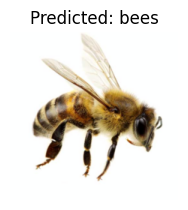

In [ ]:
visualize_model_predictions(
    model2,
    img_path='/content/honey-bee.jpg'
)

plt.ioff()
plt.show()

In [ ]:
for param in model2.parameters():
    param.requires_grad = False

num_ftrs = model2.fc.in_features
model2.fc = nn.Linear(num_ftrs, 2)

model2 = model2.to(device)

criterion = nn.CrossEntropyLoss()

optimizer_conv = optim.SGD(model2.fc.parameters(), lr=0.001, momentum=0.9)

exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

In [ ]:
model2 = train_model(model2, criterion, optimizer_conv,
                         exp_lr_scheduler, num_epochs=25)

Epoch 0/24
----------
train Loss: 0.6194 Acc: 0.6926
val Loss: 0.4780 Acc: 0.9281

Epoch 1/24
----------
train Loss: 0.5061 Acc: 0.7951
val Loss: 0.3318 Acc: 0.9608

Epoch 2/24
----------
train Loss: 0.4541 Acc: 0.8074
val Loss: 0.2662 Acc: 0.9608

Epoch 3/24
----------
train Loss: 0.4025 Acc: 0.8689
val Loss: 0.2315 Acc: 0.9739

Epoch 4/24
----------
train Loss: 0.3687 Acc: 0.8689
val Loss: 0.2022 Acc: 0.9673

Epoch 5/24
----------
train Loss: 0.3348 Acc: 0.8770
val Loss: 0.2078 Acc: 0.9608

Epoch 6/24
----------
train Loss: 0.3049 Acc: 0.9016
val Loss: 0.1881 Acc: 0.9673

Epoch 7/24
----------
train Loss: 0.3370 Acc: 0.8689
val Loss: 0.1698 Acc: 0.9608

Epoch 8/24
----------
train Loss: 0.3198 Acc: 0.9139
val Loss: 0.1756 Acc: 0.9739

Epoch 9/24
----------
train Loss: 0.3391 Acc: 0.8484
val Loss: 0.1780 Acc: 0.9673

Epoch 10/24
----------
train Loss: 0.3188 Acc: 0.8811
val Loss: 0.1681 Acc: 0.9608

Epoch 11/24
----------
train Loss: 0.3112 Acc: 0.8648
val Loss: 0.1736 Acc: 0.9673

Ep

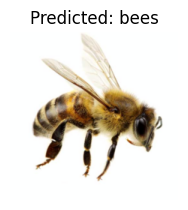

In [ ]:
visualize_model_predictions(
    model2,
    img_path='/content/honey-bee.jpg'
)

plt.ioff()
plt.show()